[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/rycroft-group/math513/blob/main/5_eigen/5_eigen.ipynb)

In [1]:
# Necessity libraries
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import scipy.sparse as sp
import scipy.sparse.linalg as spl

# Optional: a library for plotting with LaTeX-like
# styles nicer formatted figures
# Warning: need to have LaTeX installed
import scienceplots
plt.style.use(['science'])

In [2]:
import os
os.makedirs("results", exist_ok=True)

# Unit 5: Eigenvalue problems

## Lecture 26: Eigenvalue problems

### Code demo 1: Fundamental mode vibrations on a square drum

Calculate the eigenvalues and eigenmodes of the Laplacian operator on $[0,1]^2$ with zero Dirichlet boundary conditions.

In [3]:
# Grid setup
m = 40
mm = m*m
h = 1/(m+1)

# Generate the centered difference differentiation matrix for the Laplacian
hfac = 1/(h*h)
cen = np.ones(mm)*(4*hfac)
hor = np.ones(mm-1)*(-hfac)
ver = np.ones(m*(m-1))*(-hfac)
for i in range(m-1):
    hor[(i+1)*m-1] = 0
D2 = sp.diags([cen, hor, hor, ver, ver], [0, 1, -1, m, -m])

# Calculate eigenvalues and eigenvectors
vals, vecs = spl.eigs(D2, k=8, which='SM')
print("Eigenvalues:")
print(vals)

Eigenvalues:
[ 19.72955284+0.j  78.8024305 +0.j  49.26599167+0.j  49.26599167+0.j
  98.30076134+0.j  98.30076134+0.j 127.83720017+0.j 127.83720017+0.j]


In [4]:
# Assemble an eigenvector in a grid
uu = np.zeros((m+2, m+2))
for i in range(m):
    for j in range(m):
        uu[i+1, j+1] = vecs[i+m*j, 0].real

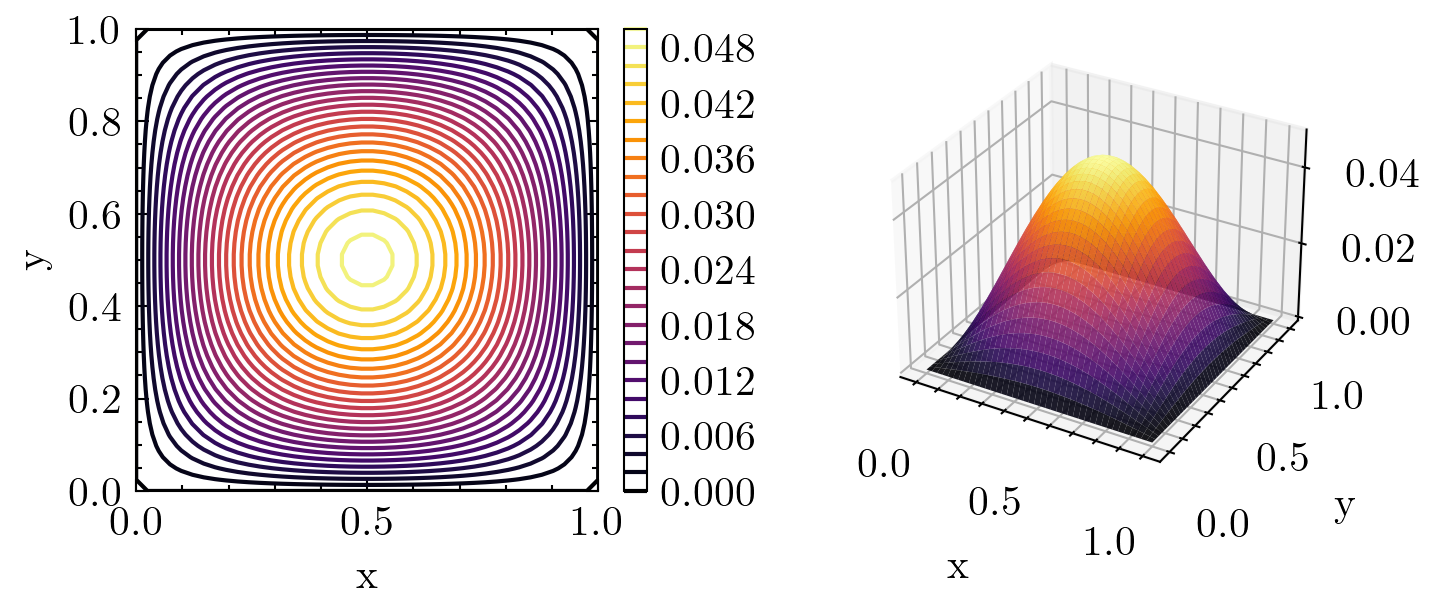

In [5]:

# Plot the eigenvector
xa = np.linspace(0, 1, m+2)
mgx, mgy = np.meshgrid(xa, xa)

fig = plt.figure(figsize=(6, 2), dpi=300)

# 2D heatmap
ax1 = fig.add_subplot(1, 2, 1)
im = ax1.contour(mgx, mgy, uu, levels=30, cmap='inferno')
ax1.set_xlabel('x')
ax1.set_ylabel('y')
ax1.set_aspect('equal', adjustable='box')
ax1.set_xlim(0, 1)
ax1.set_ylim(0, 1)
fig.colorbar(im, ax=ax1, fraction=0.046, pad=0.04)

# 3D surface plot
ax2 = fig.add_subplot(1, 2, 2, projection='3d')
ax2.plot_surface(mgx, mgy, uu, cmap='inferno',
                 edgecolor='none', alpha=0.9, rstride=1, cstride=1)
ax2.set_xlabel('x')
ax2.set_ylabel('y')
ax2.set_zlabel('u')

# plt.tight_layout()
plt.show()

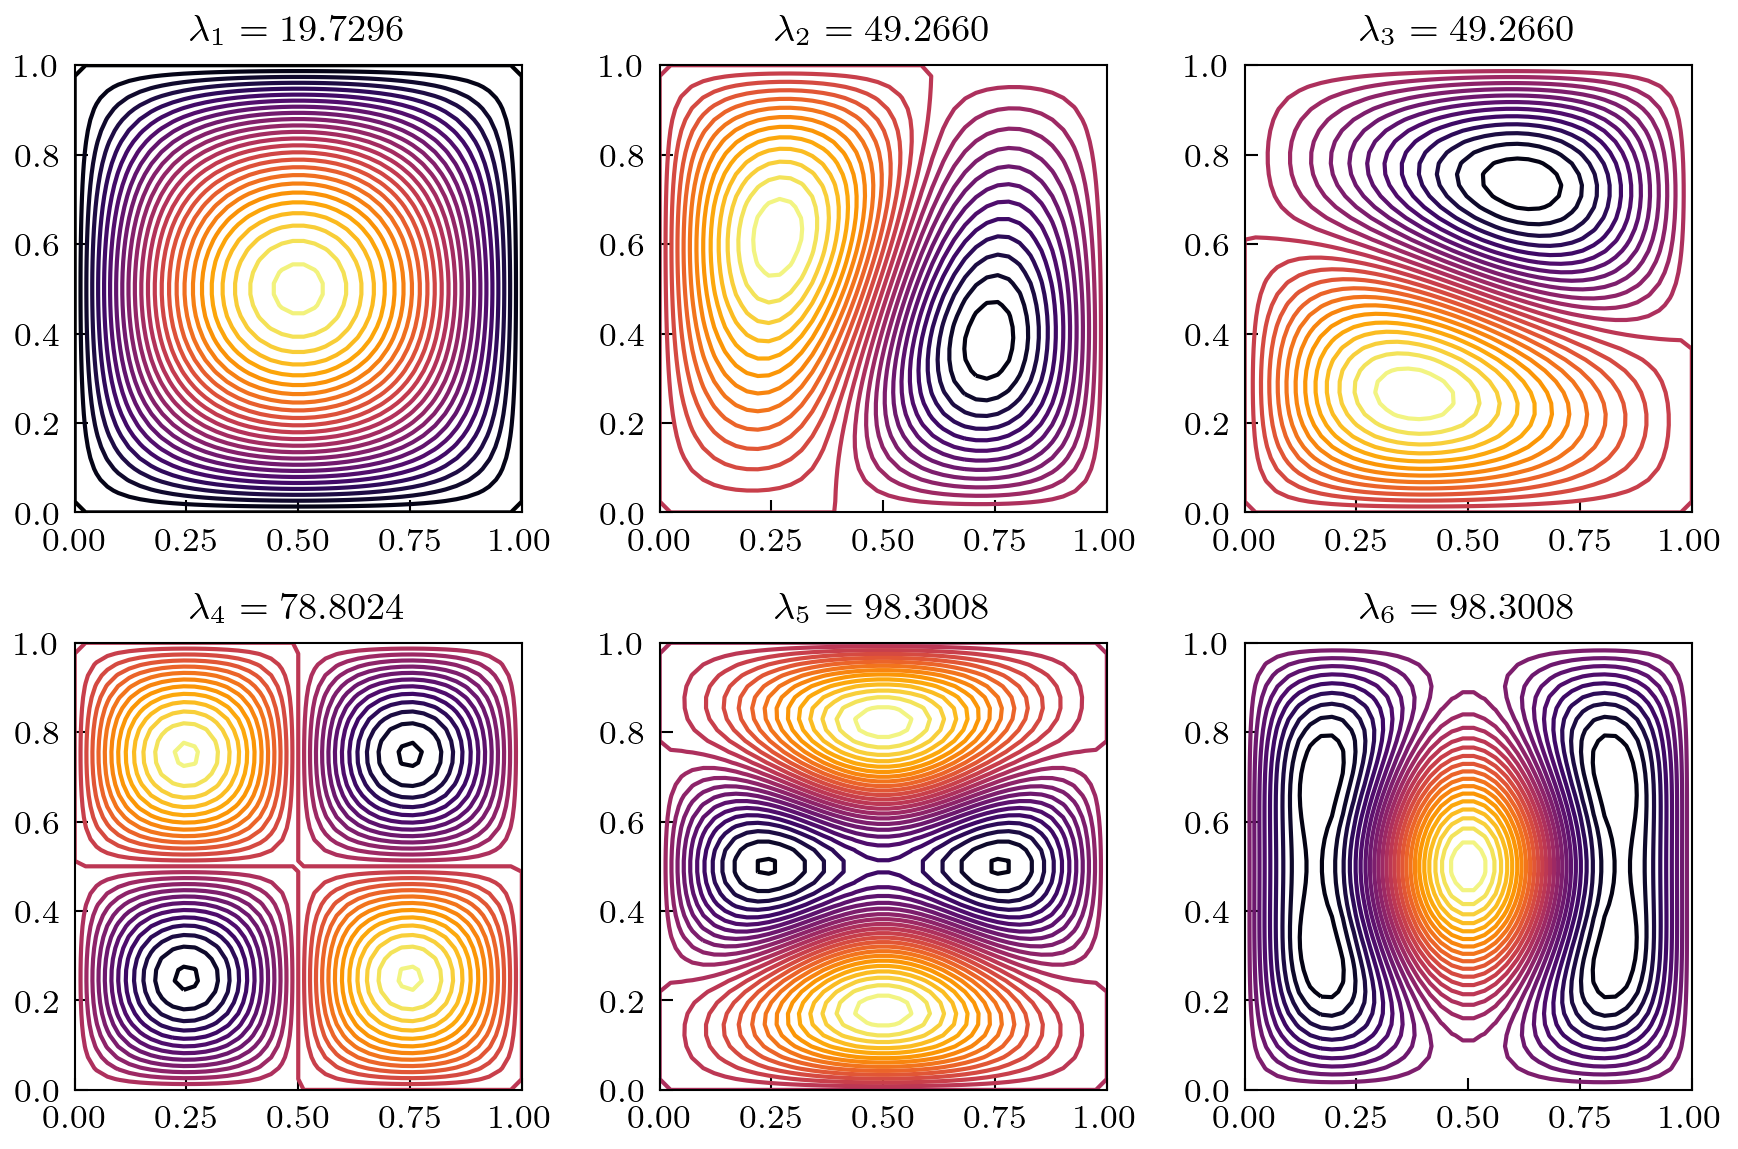

In [6]:
# Order eigenpairs by eigenvalue (ascending, using real part)
order = np.argsort(vals.real)
ordered_vals = vals.real[order]
first6 = order[:6]

# 2x3 contour plot of the first 6 eigenmodes
fig, axes = plt.subplots(2, 3, figsize=(6, 4), dpi=300)

for k, idx in enumerate(first6):
    ax = axes.flat[k]

    # Rebuild mode on grid with zero Dirichlet boundary
    u_mode = np.zeros((m + 2, m + 2))
    u_mode[1:-1, 1:-1] = vecs[:, idx].real.reshape((m, m), order='F')

    cs = ax.contour(mgx, mgy, u_mode, levels=30, cmap='inferno')
    ax.set_aspect('equal', adjustable='box')
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_title(f'$\\lambda_{{{k+1}}}={ordered_vals[k]:.4f}$', fontsize=9)
    # Prettify
    ax.tick_params(axis='both', which='major', labelsize=8)
    ax.tick_params(axis='both', which='minor', bottom=False, left=False)
    ax.tick_params(axis='both', which='both', right=False, top=False)

plt.tight_layout()
# plt.savefig("results/eigenmodes.png", dpi=300)
plt.show()

## Lecture 29: Power method

### Code demo 1: Power method and shifted power method

In [7]:
# Initialize the matrix and shift
A = np.array([[4., 1.], [1., -2.]])
shift = -4.2

# Choose an initial guess and set iteration counter
np.random.seed(42)
x = np.random.randn(2)
count = 1

# Perform iteration until the relative eigenvalue change is below a
# tolerance
rel_change = 1
lam = 1e30
while rel_change > 1e-6:
    lam_old = lam
    x_old = x

    # Power method steps
    y = np.dot((A-shift*np.eye(2)), x)
    x = y/np.linalg.norm(y)

    # Estimate lambda by comparing an entry of y and x_old
    lam = y[1]/x_old[1]
    print("Iteration %d: lam=%.10g" % (count, lam))
    count += 1

    # Compute the relative change in the estimate of lambda
    rel_change = abs((lam-lam_old)/lam)

# Apply shift
lam = lam+shift

print("\nPower method with shift %d converged to %g" % (shift, lam))

Iteration 1: lam=-1.392497476
Iteration 2: lam=22.63700602
Iteration 3: lam=9.647250278
Iteration 4: lam=8.63369359
Iteration 5: lam=8.426337184
Iteration 6: lam=8.377769032
Iteration 7: lam=8.366045622
Iteration 8: lam=8.363195425
Iteration 9: lam=8.362501277
Iteration 10: lam=8.36233215
Iteration 11: lam=8.362290938
Iteration 12: lam=8.362280896
Iteration 13: lam=8.362278449

Power method with shift -4 converged to 4.16228


## Lecture 30: Inverse iteration, Rayleigh quotient

### Code demo 1: Inverse iteration

In [8]:
# Initialize the matrix
A = np.array([[6, 1, 2], [1, 0, -4], [2, -4, 4]])

# Print reference eigenvalues
vals, _ = np.linalg.eig(A)
print("Reference eigenvalues: ", vals)

# Store outputs for plotting
results = []

# Loop over a range of shifts
for shift in np.linspace(-10, 10, 201):

    # Set up starting vector
    x = np.array((1, 0.7, 0.3))
    count = 1

    # Perform inverse iteration until the relative eigenvalue change is
    # below a tolerance
    rel_change = 1
    lam = 1e30
    while rel_change > 1e-8:
        lam_old = lam
        x_old = x

        # Solve linear system and normalize
        y = np.linalg.solve((A-shift*np.eye(3)), x)
        x = y/np.linalg.norm(y)

        # Estimate eigenvalue by comparing an entry of y and x_old
        lam = y[1]/x_old[1]
        rel_change = abs((lam-lam_old)/lam)
        count += 1

    # Output the shift, the computed eigenvalue, and the number of
    # iterations required
    print(shift, 1/lam+shift, count)
    results.append((shift, 1/lam+shift, count))

Reference eigenvalues:  [-2.88616985  7.59272334  5.29344651]
-10.0 -2.886169803264086 26
-9.9 -2.8861698106778224 26
-9.8 -2.8861698169286454 26
-9.7 -2.8861697934700263 25
-9.6 -2.8861698027616933 25
-9.5 -2.8861698105674902 25
-9.4 -2.8861698170985512 25
-9.3 -2.8861698225401966 25
-9.2 -2.8861698023656848 24
-9.1 -2.886169810580995 24
-9.0 -2.8861698173964614 24
-8.9 -2.8861698230245114 24
-8.8 -2.8861698276497654 24
-8.7 -2.8861698107552796 23
-8.6 -2.886169817853471 23
-8.5 -2.886169823656603 23
-8.4 -2.8861698283756603 23
-8.3 -2.8861698111364236 22
-8.2 -2.88616981850695 22
-8.1 -2.8861698244650063 22
-8.0 -2.8861698292524602 22
-7.9 -2.8861698330752823 22
-7.8 -2.886169819401082 21
-7.699999999999999 -2.8861698254817227 21
-7.6 -2.8861698303012746 21
-7.5 -2.8861698340941935 21
-7.4 -2.8861698370569826 21
-7.3 -2.8861698267411056 20
-7.199999999999999 -2.886169831542344 20
-7.1 -2.8861698352574816 20
-7.0 -2.886169838107582 20
-6.9 -2.8861698282772466 19
-6.8 -2.88616983299187

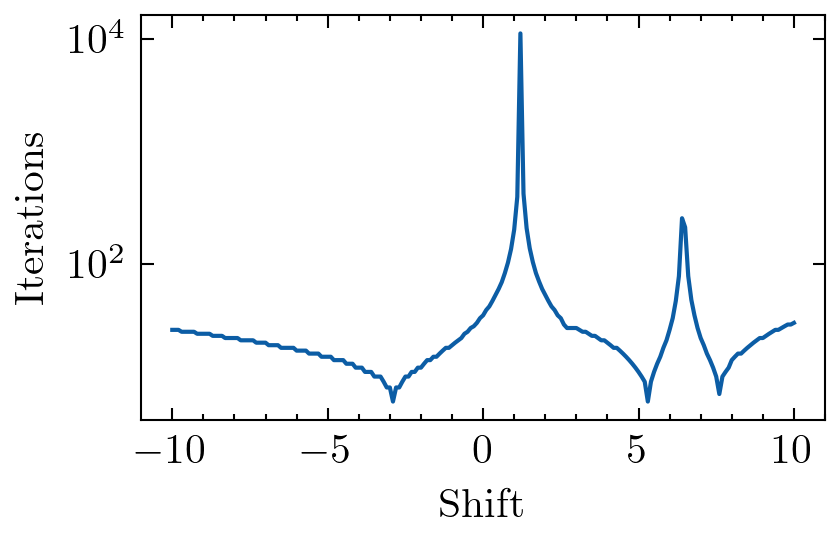

In [9]:
# Unpack result
shifts, eigenvalues, iterations = zip(*results)

fig, ax = plt.subplots(1, 1, figsize=(3, 2), dpi=300)
ax.plot(shifts, iterations, '-')
# Prettify
ax.set_xlabel('Shift')
ax.set_ylabel('Iterations')
ax.set_yscale('log')
plt.tight_layout()
# plt.savefig("results/inverse_iteration.png", dpi=300)
plt.show()

### Code demo 2: Rayleigh quotient iteration 

In [10]:
# Setup
A = np.array([[5., 1., 1], [1., 6., 1.], [1., 1., 7.]])
x = np.array([[1], [1], [1]])/np.sqrt(3)

# Compute reference solution
[V, D] = np.linalg.eig(A)
eig_solution = V[0]

# set a tolerance and initialize guess of eigenvalue
TOL = 1.e-10
sig = 1e30

# Perform Rayleigh Quotient Iteration
count = 1
while 1:
    sig_old = sig

    # Calculate Rayleigh quotient
    sig = np.dot(np.dot(x.T, A), x)/np.dot(x.T, x)

    # Perform inverse iteration
    A_shifted = A-sig*np.eye(3)
    y = np.linalg.solve(A_shifted, x)
    x = y/np.linalg.norm(y)

    sig_diff = abs((sig-sig_old)/sig)

    print("Iteration %d: eigenvalue error=%.10g" %
          (count, abs(sig-eig_solution)))

    # Break out of the loop if lambda_diff < TOL
    if sig_diff < TOL:
        break

    count = count+1

print("\nEigenvalues from eig are", V[0], V[1], V[2])
print("Eigenvalue from Rayleigh iteration is", sig[0, 0])

Iteration 1: eigenvalue error=0.2143197434
Iteration 2: eigenvalue error=0.001204989279
Iteration 3: eigenvalue error=1.934967742e-10
Iteration 4: eigenvalue error=7.105427358e-15

Eigenvalues from eig are 8.214319743377528 4.32486912943335 5.46081112718911
Eigenvalue from Rayleigh iteration is 8.214319743377535


/var/folders/dc/yjt5l_9s0d752c4rt46gd2qh0000gn/T/ipykernel_74764/417375587.py:28: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print("Iteration %d: eigenvalue error=%.10g" %


## Lecture 31: QR algorithm

### Code demo 1: QR algorithm

In [11]:
A = np.matrix([[2.9766, 0.3945, 0.4198, 1.1159],
               [0.3945, 2.7328, -0.3097, 0.1129],
               [0.4198, -0.3097, 2.5675, 0.6079],
               [1.1159, 0.1129, 0.6079, 1.7231]])
max_iters = 100

# Initialize A_k
A_k = A

# Initialize the matrix in which we store the product of our Q matrices
Q_prod = np.eye(4)

# Perform the QR algorithm
for i in range(max_iters):
    (Q_k, R_k) = np.linalg.qr(A_k)
    A_k = np.dot(R_k, Q_k)
    Q_prod = np.dot(Q_prod, Q_k)

# Print eigenvalues
print(np.diag(A_k))

# Print eigenvectors
print(Q_prod)

print(np.linalg.eig(A))

[4.00002176 2.99997495 2.00001946 0.99998383]
[[ 0.76055983  0.13540006 -0.4522908  -0.44570011]
 [ 0.18497226  0.81511916  0.54893289  0.00622023]
 [ 0.38903703 -0.55818571  0.70021691 -0.21627571]
 [ 0.48578204 -0.07534114 -0.06166026  0.8686412 ]]
EigResult(eigenvalues=array([4.00002176, 0.99998383, 2.00001946, 2.99997495]), eigenvectors=matrix([[ 0.76055983,  0.44570011,  0.4522908 , -0.13540006],
        [ 0.18497226, -0.00622023, -0.54893289, -0.81511916],
        [ 0.38903703,  0.21627571, -0.70021691,  0.55818571],
        [ 0.48578204, -0.8686412 ,  0.06166026,  0.07534114]]))
